Milestone 3 – Zone-level Time Series & Demand Prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [2]:
uber15 = pd.read_csv("C:\\Users\\jeffr\\OneDrive\\Desktop\\motorq_hackathon_practice\\data\\raw\\uber_2015\\uber-raw-data-janjune-15.csv")
uber15.head()


,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-17 09:47:00,B02617,141
1,B02617,2015-05-17 09:47:00,B02617,65
2,B02617,2015-05-17 09:47:00,B02617,100
3,B02617,2015-05-17 09:47:00,B02774,80
4,B02617,2015-05-17 09:47:00,B02617,90


Same as Uber 2014 in meaning, but not in structure.. Pickup_date is the timestamp It is currently a string, not datetime..The data is already zone-based Spatial mapping is cleaner than 2014 You will rely on taxi-zone lookup

In [3]:
uber15.info()
uber15.shape

<class 'pandas.DataFrame'>
RangeIndex: 14270479 entries, 0 to 14270478
Data columns (total 4 columns):
 #   Column                Dtype
---  ------                -----
 0   Dispatching_base_num  str  
 1   Pickup_date           str  
 2   Affiliated_base_num   str  
 3   locationID            int64
dtypes: int64(1), str(3)
memory usage: 435.5 MB


(14270479, 4)

From inspecting the Uber 2015 dataset, each row represents a single pickup event. The dataset contains over 14 million records, indicating large-scale, high-volume operational data that requires early aggregation for analysis.

Unlike Uber 2014, spatial information is represented using a LocationID rather than latitude and longitude. This suggests that the data is already standardized at a zone level, making it more suitable for zone-based demand analysis when combined with the taxi zone lookup table.

The pickup timestamp is stored in the Pickup_date column as a string and will need to be converted to a datetime type before any time-series analysis. The presence of both Dispatching_base_num and Affiliated_base_num indicates richer operational metadata compared to earlier datasets, although these fields are secondary to the primary goal of zone-level demand prediction.

Overall, Uber 2015 data is structurally better suited for zone-level, time-series demand modeling than Uber 2014, but its large size requires careful aggregation and feature engineering.




Uber 2015 better suited for zone-level demand modeling than Uber 2014

🔹 Step 2.1: Convert pickup time to datetime

In [5]:
uber15["Pickup_date"] = pd.to_datetime(uber15["Pickup_date"])
uber15["Pickup_date"].dtype



dtype('<M8[us]')

🔹 Step 2.2: Create time features (minimal, correct)

In [6]:
uber15["hour"] = uber15["Pickup_date"].dt.hour
uber15["date"] = uber15["Pickup_date"].dt.date


🔹 Step 2.3: Create hourly zone-level demand (CORE STEP)

In [ ]:
zone_hour_demand = (
    uber15
    .groupby(["locationID", "date", "hour"])
    .size()
    .reset_index(name="pickup_count")
)

zone_hour_demand.head()

#What ONE row now represents: Number of pickups in one zone, during one hour, on one day

,locationID,date,hour,pickup_count
0,1,2015-01-01,15,1
1,1,2015-01-05,6,1
2,1,2015-01-08,6,1
3,1,2015-01-10,8,1
4,1,2015-01-12,11,1


Step 3: Handling Missing Hours

why is this important?? 
Every hour to exist — even if pickup_count = 0
If a zone had zero pickups at some hour
➡️ that hour is missing, not recorded as 0

This is dangerous because:

Models think “no row” ≠ “zero demand”

Lag features break

Rolling averages break

Time-series continuity is lost

👉 In time series, missing ≠ zero
We must make that explicit.

In [8]:
# Step 3.1: Create a full hourly time grid
zone_hour_demand["timestamp"] = pd.to_datetime(
    zone_hour_demand["date"].astype(str)
) + pd.to_timedelta(zone_hour_demand["hour"], unit="h")


In [10]:
# Step 3.2: Create a complete time index
full_time_index = pd.date_range(
    start=zone_hour_demand["timestamp"].min(),
    end=zone_hour_demand["timestamp"].max(),
    freq="h"
)


In [12]:
#Step 3.3: Reindex per zone (THIS IS THE KEY PART)
zone_ts = (
    zone_hour_demand
    .set_index("timestamp")
    .groupby("locationID")
    .apply(lambda x: x.reindex(full_time_index))
    .reset_index()
)

zone_ts = zone_ts.rename(columns={"level_1": "timestamp"})
zone_ts.head()

,locationID,timestamp,date,hour,pickup_count
0,1,2015-01-01 00:00:00,NaN,NaN,NaN
1,1,2015-01-01 01:00:00,NaN,NaN,NaN
2,1,2015-01-01 02:00:00,NaN,NaN,NaN
3,1,2015-01-01 03:00:00,NaN,NaN,NaN
4,1,2015-01-01 04:00:00,NaN,NaN,NaN


In [ ]:
# Step 3.4: Fill missing pickup counts with 0
zone_ts["pickup_count"] = zone_ts["pickup_count"].fillna(0)
zone_ts.head()

,locationID,timestamp,date,hour,pickup_count
0,1,2015-01-01 00:00:00,NaN,NaN,0.0
1,1,2015-01-01 01:00:00,NaN,NaN,0.0
2,1,2015-01-01 02:00:00,NaN,NaN,0.0
3,1,2015-01-01 03:00:00,NaN,NaN,0.0
4,1,2015-01-01 04:00:00,NaN,NaN,0.0


In [16]:
zone_ts["date"] = zone_ts["timestamp"].dt.date
zone_ts["hour"] = zone_ts["timestamp"].dt.hour
zone_ts["weekday"] = zone_ts["timestamp"].dt.weekday
zone_ts["pickup_count"] = zone_ts["pickup_count"].astype(int)
zone_ts.head()

,locationID,timestamp,date,hour,pickup_count,weekday
0,1,2015-01-01 00:00:00,2015-01-01,0,0,3
1,1,2015-01-01 01:00:00,2015-01-01,1,0,3
2,1,2015-01-01 02:00:00,2015-01-01,2,0,3
3,1,2015-01-01 03:00:00,2015-01-01,3,0,3
4,1,2015-01-01 04:00:00,2015-01-01,4,0,3


Step 4: Feature Engineering

In [19]:
# Step 4.1: Sort correctly (VERY IMPORTANT)
zone_ts = zone_ts.sort_values(
    ["locationID", "timestamp"]
).reset_index(drop=True)

zone_ts


,locationID,timestamp,date,hour,pickup_count,weekday
0,1,2015-01-01 00:00:00,2015-01-01,0,0,3
1,1,2015-01-01 01:00:00,2015-01-01,1,0,3
2,1,2015-01-01 02:00:00,2015-01-01,2,0,3
3,1,2015-01-01 03:00:00,2015-01-01,3,0,3
4,1,2015-01-01 04:00:00,2015-01-01,4,0,3
...,...,...,...,...,...,...
1138123,265,2015-06-30 19:00:00,2015-06-30,19,3,1
1138124,265,2015-06-30 20:00:00,2015-06-30,20,3,1
1138125,265,2015-06-30 21:00:00,2015-06-30,21,0,1
1138126,265,2015-06-30 22:00:00,2015-06-30,22,2,1


In [23]:
#Step 4.2: Lag features

zone_ts["lag_1"] = (
    zone_ts
    .groupby("locationID")["pickup_count"]
    .shift(1)
)

zone_ts["lag_24"] = (
    zone_ts
    .groupby("locationID")["pickup_count"]
    .shift(24)
)

zone_ts


,locationID,timestamp,date,hour,pickup_count,weekday,lag_1,lag_24
0,1,2015-01-01 00:00:00,2015-01-01,0,0,3,NaN,NaN
1,1,2015-01-01 01:00:00,2015-01-01,1,0,3,0.0,NaN
2,1,2015-01-01 02:00:00,2015-01-01,2,0,3,0.0,NaN
3,1,2015-01-01 03:00:00,2015-01-01,3,0,3,0.0,NaN
4,1,2015-01-01 04:00:00,2015-01-01,4,0,3,0.0,NaN
...,...,...,...,...,...,...,...,...
1138123,265,2015-06-30 19:00:00,2015-06-30,19,3,1,4.0,2.0
1138124,265,2015-06-30 20:00:00,2015-06-30,20,3,1,3.0,1.0
1138125,265,2015-06-30 21:00:00,2015-06-30,21,0,1,3.0,2.0
1138126,265,2015-06-30 22:00:00,2015-06-30,22,2,1,0.0,1.0


In [25]:
#✅ Step 4.3: Rolling averages (trend signal)

zone_ts["rolling_3"] = (
    zone_ts
    .groupby("locationID")["pickup_count"]
    .shift(1)
    .rolling(3)
    .mean()
)

zone_ts["rolling_24"] = (
    zone_ts
    .groupby("locationID")["pickup_count"]
    .shift(1)
    .rolling(24)
    .mean()
)
zone_ts


,locationID,timestamp,date,hour,pickup_count,weekday,lag_1,lag_24,rolling_3,rolling_24
0,1,2015-01-01 00:00:00,2015-01-01,0,0,3,NaN,NaN,NaN,NaN
1,1,2015-01-01 01:00:00,2015-01-01,1,0,3,0.0,NaN,NaN,NaN
2,1,2015-01-01 02:00:00,2015-01-01,2,0,3,0.0,NaN,NaN,NaN
3,1,2015-01-01 03:00:00,2015-01-01,3,0,3,0.0,NaN,0.000000,NaN
4,1,2015-01-01 04:00:00,2015-01-01,4,0,3,0.0,NaN,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...
1138123,265,2015-06-30 19:00:00,2015-06-30,19,3,1,4.0,2.0,2.333333,1.583333
1138124,265,2015-06-30 20:00:00,2015-06-30,20,3,1,3.0,1.0,3.000000,1.625000
1138125,265,2015-06-30 21:00:00,2015-06-30,21,0,1,3.0,2.0,3.333333,1.708333
1138126,265,2015-06-30 22:00:00,2015-06-30,22,2,1,0.0,1.0,2.000000,1.625000


Step 5.1: Define “high demand”

In [28]:
threshold = zone_ts["pickup_count"].quantile(0.80)
threshold


np.float64(15.0)

The 80th percentile threshold of 15 pickups indicates that only the top 20% of zone-hour combinations are classified as high demand, enabling a balanced and business-relevant definition of peak demand.

In [29]:
#Step 5.2: Create the target variable
zone_ts["high_demand"] = (zone_ts["pickup_count"] >= threshold).astype(int)


Step 6: Prepare Modeling Dataset

In [31]:
#6.1 Drop rows with NaNs (from lags)
model_df = zone_ts.dropna().copy()
model_df.shape
model_df.head()


,locationID,timestamp,date,hour,pickup_count,weekday,lag_1,lag_24,rolling_3,rolling_24,high_demand
24,1,2015-01-02 00:00:00,2015-01-02,0,0,4,0.0,0.0,0.0,0.041667,0
25,1,2015-01-02 01:00:00,2015-01-02,1,0,4,0.0,0.0,0.0,0.041667,0
26,1,2015-01-02 02:00:00,2015-01-02,2,0,4,0.0,0.0,0.0,0.041667,0
27,1,2015-01-02 03:00:00,2015-01-02,3,0,4,0.0,0.0,0.0,0.041667,0
28,1,2015-01-02 04:00:00,2015-01-02,4,0,4,0.0,0.0,0.0,0.041667,0


In [32]:
#6.2 Select features + target
features = [
    "hour",
    "weekday",
    "lag_1",
    "lag_24",
    "rolling_3",
    "rolling_24"
]

X = model_df[features]
y = model_df["high_demand"]


In [33]:
y.value_counts(normalize=True)


high_demand
0    0.792264
1    0.207736
Name: proportion, dtype: float64

Train the Baseline Model (Logistic Regression)

🎯 What we are predicting (restate clearly)

Given zone + hour + recent demand patterns, predict whether demand will be HIGH (1) or NORMAL (0).

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False   # VERY IMPORTANT
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((905472, 6), (226368, 6), (905472,), (226368,))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # handles ~80/20 imbalance
)

model.fit(X_train, y_train)



'''
Since this is time-series data, I avoided SMOTE to prevent breaking temporal dependencies. 
Instead, I used class weighting, which handles imbalance at the loss level without altering the data.”
'''

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

           0       0.98      0.93      0.95    160220
           1       0.84      0.96      0.90     66148

    accuracy                           0.94    226368
   macro avg       0.91      0.94      0.92    226368
weighted avg       0.94      0.94      0.94    226368



array([[148465,  11755],
       [  2876,  63272]])

In [37]:
import pandas as pd
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df


,feature,coefficient
2,lag_1,0.303064
3,lag_24,0.097503
0,hour,0.050717
5,rolling_24,0.038525
1,weekday,-0.000497
4,rolling_3,-0.060522


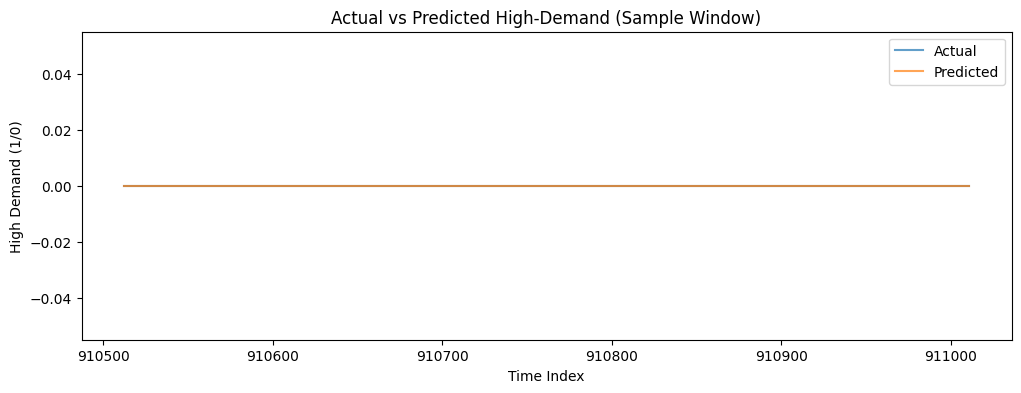

In [ ]:
import matplotlib.pyplot as plt

sample_idx = X_test.index[:500]  # small window for clarity

plt.figure(figsize=(12,4))
plt.plot(sample_idx, y_test.loc[sample_idx], label="Actual", alpha=0.7)
plt.plot(sample_idx, y_pred[:500], label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted High-Demand (Sample Window)")
plt.xlabel("Time Index")
plt.ylabel("High Demand (1/0)")
plt.legend()
plt.show()


inference :  “Indha window-la actual um zero, predicted um zero. Model oru thadava kooda 1 predict pannala. So false positive varradhukku chance eh illa. Naama false positives measure pannala simply observe pannom that there are no false alarms.”

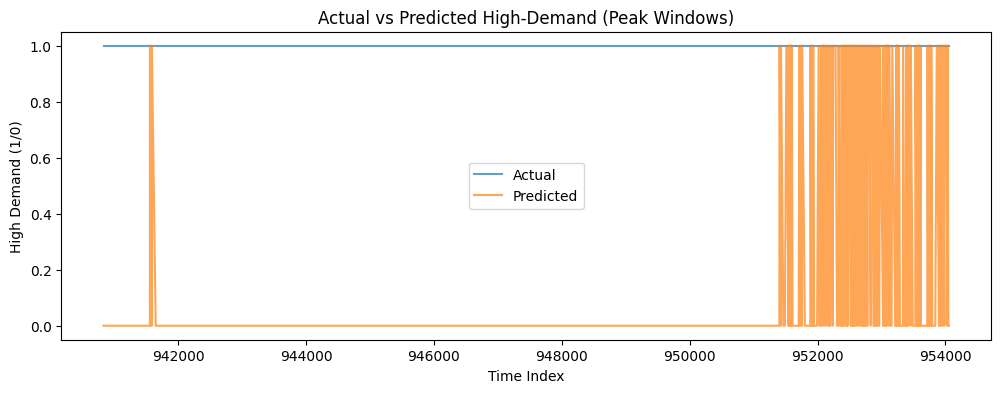

In [45]:
peak_idx = y_test[y_test == 1].index[:500]

plt.figure(figsize=(12,4))
plt.plot(peak_idx, y_test.loc[peak_idx], label="Actual", alpha=0.7)
plt.plot(peak_idx, y_pred[y_test.index.get_indexer(peak_idx)], label="Predicted", alpha=0.7)
plt.title("Actual vs Predicted High-Demand (Peak Windows)")
plt.xlabel("Time Index")
plt.ylabel("High Demand (1/0)")
plt.legend()
plt.show()


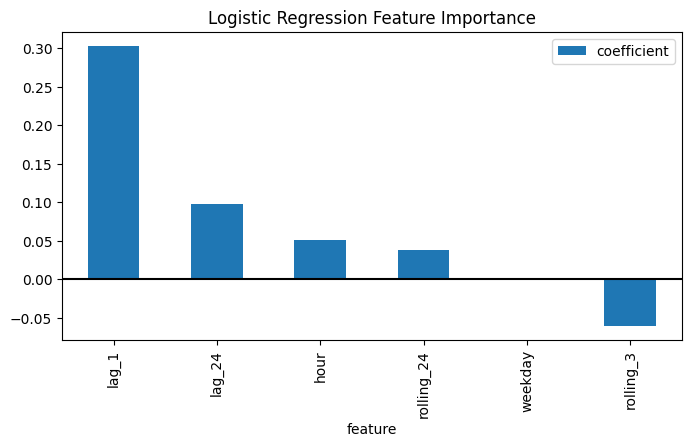

In [39]:
coef_df.plot(
    x="feature",
    y="coefficient",
    kind="bar",
    figsize=(8,4),
    title="Logistic Regression Feature Importance"
)
plt.axhline(0, color="black")
plt.show()


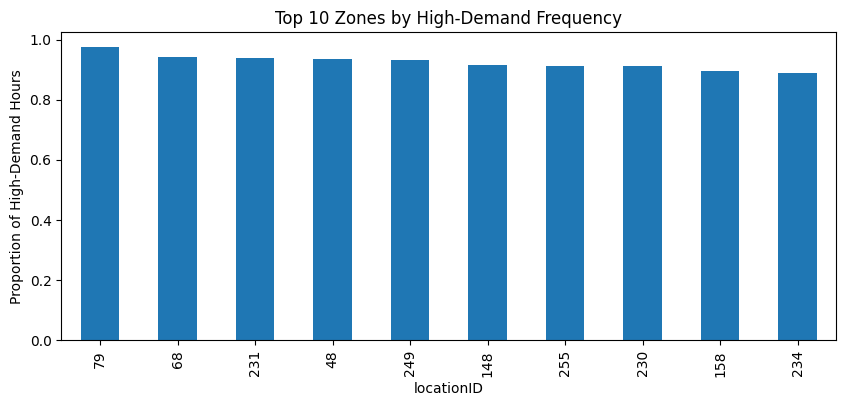

In [40]:
zone_peak_rate = (
    model_df.groupby("locationID")["high_demand"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

zone_peak_rate.plot(
    kind="bar",
    figsize=(10,4),
    title="Top 10 Zones by High-Demand Frequency"
)
plt.ylabel("Proportion of High-Demand Hours")
plt.show()
